In [6]:
import pennylane as qp
import numpy as np
import matplotlib.pyplot as plt

dev = qp.device("default.qubit", wires=1)

In [3]:
@qp.qnode(dev)
def apply_rx_pi(state):
    """Apply an RX gate with an angle of pi to a particular basis state.

    Args:
        state (int): Either 0 or 1. If 1, initialize the qubit to state |1>
            before applying other operations.

    Returns:
        np.array[complex]: The state of the qubit after the operations.
    """
    if state == 1:
        qp.PauliX(wires=0)

    # APPLY RX(pi) AND RETURN THE STATE
    qp.RX(np.pi, 0)

    return qp.state()

In [4]:
print(apply_rx_pi(0))
print(apply_rx_pi(1))

[6.123234e-17+0.j 0.000000e+00-1.j]
[0.000000e+00-1.j 6.123234e-17+0.j]


In [5]:
@qp.qnode(dev)
def apply_rx(theta, state):
    """Apply an RX gate with an angle of theta to a particular basis state.

    Args:
        theta (float): A rotation angle.
        state (int): Either 0 or 1. If 1, initialize the qubit to state |1>
            before applying other operations.

    Returns:
        np.array[complex]: The state of the qubit after the operations.
    """
    if state == 1:
        qp.PauliX(wires=0)

    # APPLY RX(theta) AND RETURN THE STATE
    qp.RX(theta, 0)

    return qp.state()

In [7]:
def plotter(angles, output_states):
    """Plot the real and imaginary parts of qubit amplitudes vs. angle."""
    output_states = np.array(output_states)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(angles, output_states[:, 0].real, label=r"Re($\alpha$)")
    ax.plot(angles, output_states[:, 0].imag, label=r"Im($\alpha$)")
    ax.plot(angles, output_states[:, 1].real, label=r"Re($\beta$)")
    ax.plot(angles, output_states[:, 1].imag, label=r"Im($\beta$)")
    
    ax.set_xlabel(r"$\theta$")
    ax.set_ylabel("Amplitude")
    ax.set_title("State amplitudes vs. rotation angle")
    ax.legend()
    ax.grid(True)
    plt.show()
    return fig

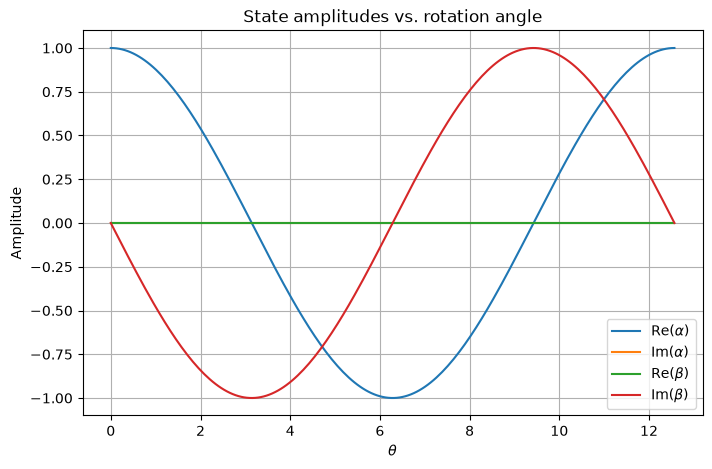

In [8]:
angles = np.linspace(0, 4 * np.pi, 200)
output_states = np.array([apply_rx(t, 0) for t in angles])

plot = plotter(angles, output_states)

In [9]:
@qp.qnode(dev)
def apply_ry(theta, state):
    """Apply an RY gate with an angle of theta to a particular basis state.

    Args:
        theta (float): A rotation angle.
        state (int): Either 0 or 1. If 1, initialize the qubit to state |1>
            before applying other operations.

    Returns:
        np.array[complex]: The state of the qubit after the operations.
    """
    if state == 1:
        qp.PauliX(wires=0)

    # APPLY RY(theta) AND RETURN THE STATE
    qp.RY(theta, 0)
    
    return qp.state()

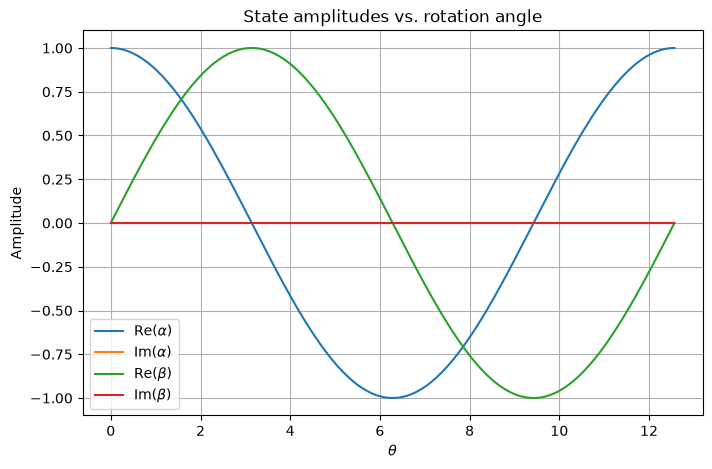

In [10]:
angles = np.linspace(0, 4 * np.pi, 200)
output_states = np.array([apply_ry(t, 0) for t in angles])

plot = plotter(angles, output_states)